# **Basic Image Operations: Image Enhancement**

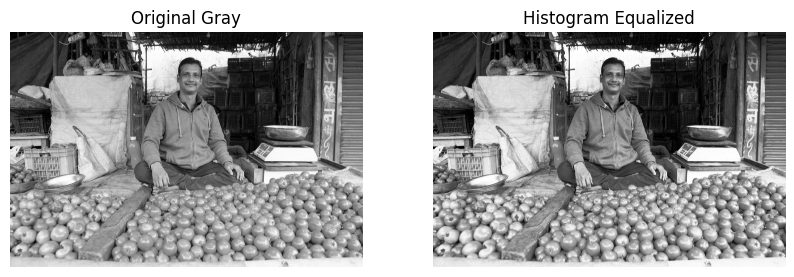

In [2]:
import cv2
from matplotlib import pyplot as plt

# Load image in grayscale
gray = cv2.imread("/content/51.jpg", cv2.IMREAD_GRAYSCALE)

# Apply Histogram Equalization
equalized = cv2.equalizeHist(gray)

# Display
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(gray, cmap='gray'), plt.title('Original Gray'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(equalized, cmap='gray'), plt.title('Histogram Equalized'), plt.axis('off')
plt.show()


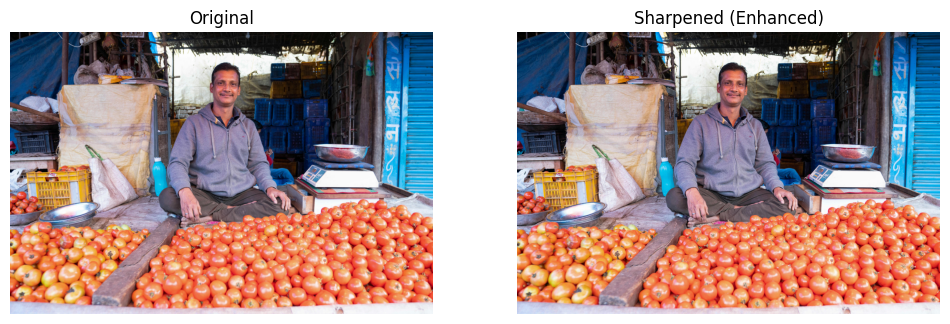

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('/content/51.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Apply Gaussian Blur
blurred = cv2.GaussianBlur(image, (0, 0), 3)

# Unsharp masking: sharpen the image
sharpened = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

# Display
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(image)
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Sharpened (Enhanced)')
plt.imshow(sharpened)
plt.axis('off')

plt.show()


In [7]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the image
image = cv2.imread('/content/51.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# ----------------------
# Simulate motion blur
def motion_blur_kernel(size):
    kernel = np.zeros((size, size))
    kernel[int((size-1)/2), :] = np.ones(size)
    return kernel / size

size = 15
psf = motion_blur_kernel(size)
blurred = cv2.filter2D(gray, -1, psf)

# ----------------------
# Inverse Filtering
def inverse_filter(img, psf):
    img_f = np.fft.fft2(img)
    psf_f = np.fft.fft2(psf, s=img.shape)
    psf_f[np.abs(psf_f) < 1e-3] = 1e-3  # Avoid division by zero
    result_f = img_f / psf_f
    result = np.abs(np.fft.ifft2(result_f))
    return np.uint8(np.clip(result, 0, 255))

restored = inverse_filter(blurred, psf)

# ----------------------
# Apply Median Filter (for salt and pepper noise removal)
median_filtered = cv2.medianBlur(gray, 5)

# ----------------------
# Add Salt and Pepper Noise
def add_salt_and_pepper(img, amount=0.02):
    noisy = img.copy()
    num_salt = np.ceil(amount * img.size * 0.5)
    num_pepper = np.ceil(amount * img.size * 0.5)

    # Salt
    # Generate coordinates for salt noise
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img.shape]
    # Correctly index into the noisy image using the generated coordinates
    noisy[coords[0], coords[1]] = 255

    # Pepper
    # Generate coordinates for pepper noise
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img.shape]
    # Correctly index into the noisy image using the generated coordinates
    noisy[coords[0], coords[1]] = 0

    return noisy

noisy_img = add_salt_and_pepper(gray)

# ----------------------
# Gaussian Filtering
gaussian_filtered = cv2.GaussianBlur(gray, (5, 5), 1.5)

# ----------------------
# Adaptive Filtering (using Adaptive Bilateral Filter here)
adaptive_filtered = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

# ----------------------
# Display all
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1), plt.imshow(gray, cmap='gray'), plt.title('Original Gray'), plt.axis('off')
plt.subplot(2, 3, 2), plt.imshow(blurred, cmap='gray'), plt.title('Motion Blurred'), plt.axis('off')
plt.subplot(2, 3, 3), plt.imshow(restored, cmap='gray'), plt.title('Inverse Filter Restored'), plt.axis('off')
plt.subplot(2, 3, 4), plt.imshow(median_filtered, cmap='gray'), plt.title('Median Filtered'), plt.axis('off')
plt.subplot(2, 3, 5), plt.imshow(noisy_img, cmap='gray'), plt.title('Salt & Pepper Noise'), plt.axis('off')
plt.subplot(2, 3, 6), plt.imshow(gaussian_filtered, cmap='gray'), plt.title('Gaussian Filtered'), plt.axis('off')

plt.tight_layout()
plt.show()

# Adaptive Bilateral Filtering Display
plt.figure(figsize=(6,6))
plt.imshow(adaptive_filtered, cmap='gray')
plt.title('Adaptive Bilateral Filtered')
plt.axis('off')
plt.show()


Output hidden; open in https://colab.research.google.com to view.

# **Image Analysis:Edge Detection**

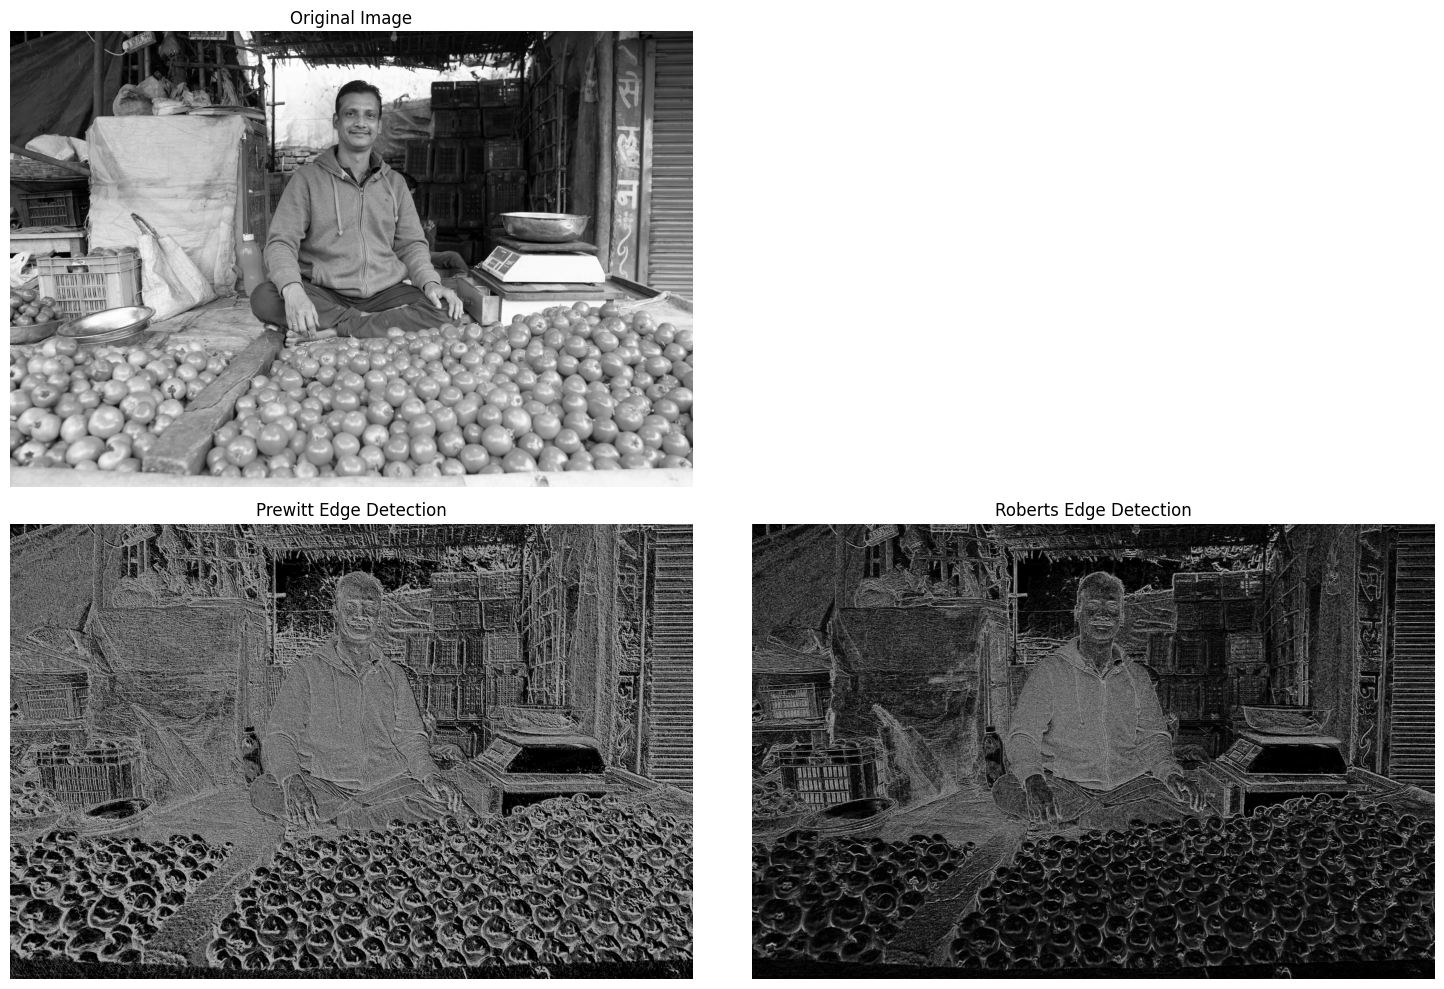

In [9]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the image
image = cv2.imread('/content/51.jpg', cv2.IMREAD_GRAYSCALE)

# Display original image
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')



# ------------------------
# Prewitt Edge Detection
kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewittx = cv2.filter2D(image, -1, kernelx)
prewitty = cv2.filter2D(image, -1, kernely)
edges_prewitt = np.sqrt(prewittx**2 + prewitty**2)

plt.subplot(2, 2, 3)
plt.imshow(edges_prewitt, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')

# ------------------------
# Roberts Edge Detection
kernelx = np.array([[1, 0], [0, -1]])
kernely = np.array([[0, 1], [-1, 0]])
robertsx = cv2.filter2D(image, -1, kernelx)
robertsy = cv2.filter2D(image, -1, kernely)
edges_roberts = np.sqrt(robertsx**2 + robertsy**2)

plt.subplot(2, 2, 4)
plt.imshow(edges_roberts, cmap='gray')
plt.title('Roberts Edge Detection')
plt.axis('off')

plt.tight_layout()
plt.show()


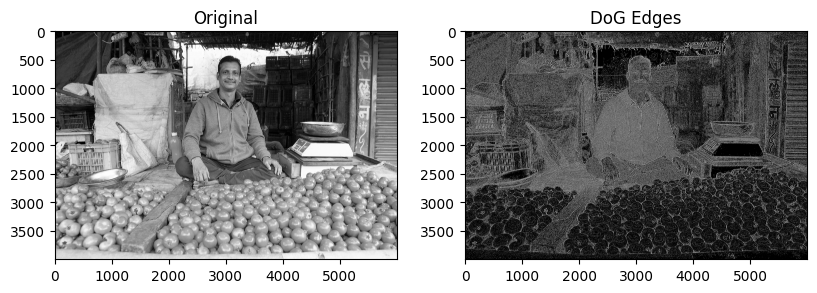

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
image = cv2.imread('/content/51.jpg', cv2.IMREAD_GRAYSCALE)

# Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(image, (5, 5), 1)

# Difference of Gaussians (DoG)
gauss1 = cv2.GaussianBlur(image, (5, 5), 1)
gauss2 = cv2.GaussianBlur(image, (5, 5), 2)
dog_edges = np.uint8(np.abs(gauss1 - gauss2))

# Display results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(image, cmap='gray'), plt.title('Original')
plt.subplot(1, 3, 2), plt.imshow(dog_edges, cmap='gray'), plt.title('DoG Edges')
plt.show()

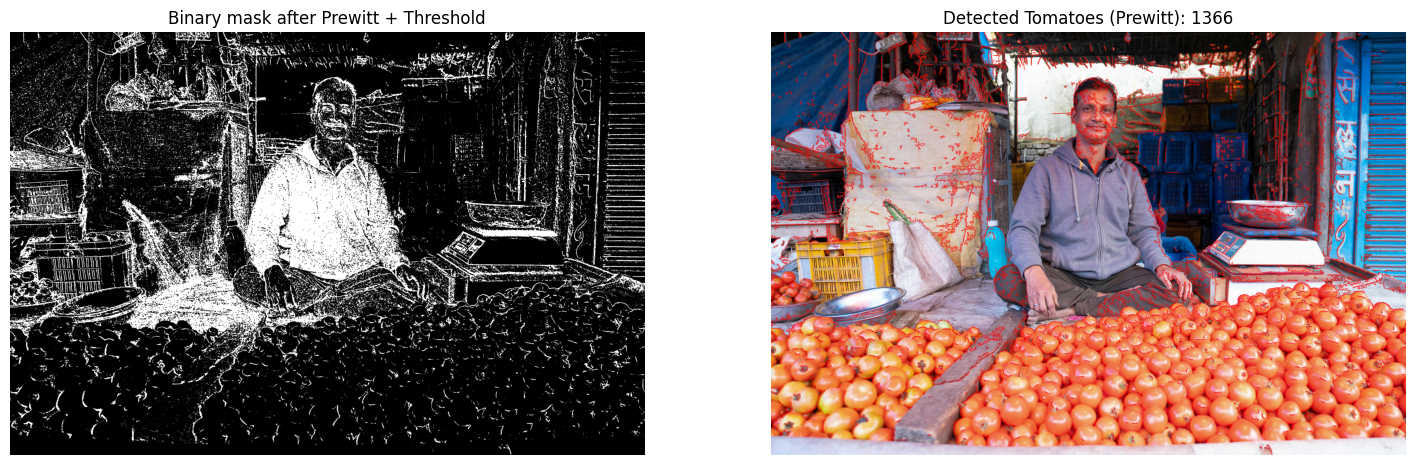

Number of tomatoes detected (Prewitt method): 1366


In [13]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the original color image
image = cv2.imread('/content/51.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ---------------------
# Prewitt Edge Detection
kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewittx = cv2.filter2D(gray, -1, kernelx)
prewitty = cv2.filter2D(gray, -1, kernely)
edges_prewitt = np.sqrt(prewittx.astype(np.float64)**2 + prewitty.astype(np.float64)**2)
edges_prewitt = np.uint8(edges_prewitt)

# ---------------------
# Threshold the Prewitt output to get binary mask
_, binary = cv2.threshold(edges_prewitt, 30, 255, cv2.THRESH_BINARY)

# Morphological closing to close gaps inside tomatoes
kernel = np.ones((5,5), np.uint8)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# Find contours
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter small contours
min_area = 100  # Minimum area to qualify as a tomato
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

# Draw contours
result_image = image_rgb.copy()
cv2.drawContours(result_image, filtered_contours, -1, (255, 0, 0), 2)  # Blue contours

# Count
tomato_count = len(filtered_contours)

# ---------------------
# Display
plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.imshow(closed, cmap='gray')
plt.title('Binary mask after Prewitt + Threshold')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result_image)
plt.title(f'Detected Tomatoes (Prewitt): {tomato_count}')
plt.axis('off')
plt.show()

print(f"Number of tomatoes detected (Prewitt method): {tomato_count}")


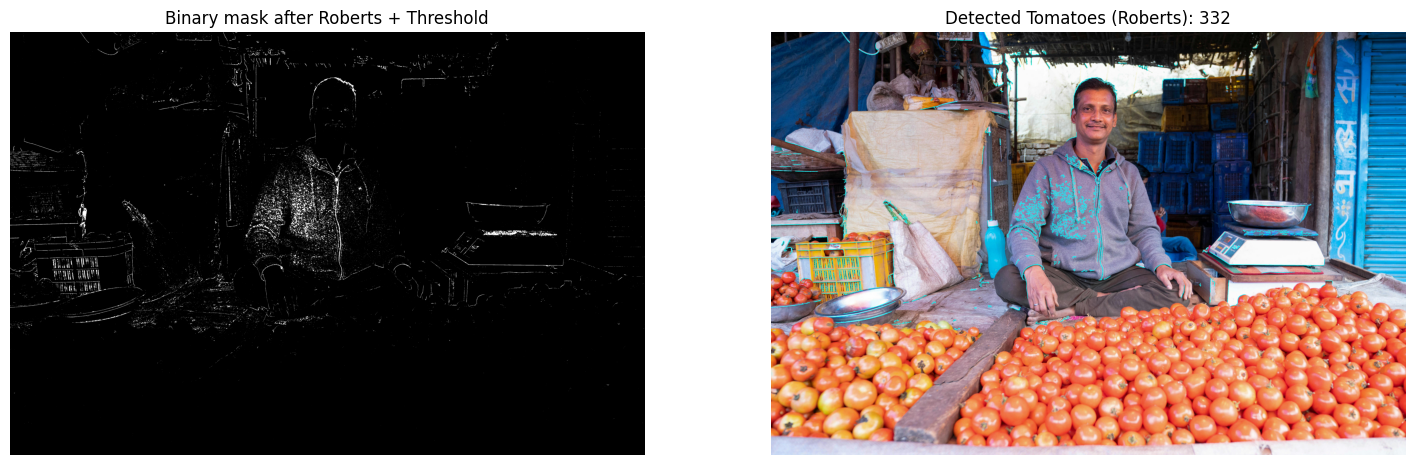

Number of tomatoes detected (Roberts method): 332


In [14]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the original color image
image = cv2.imread('/content/51.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ---------------------
# Roberts Edge Detection
kernelx = np.array([[1, 0], [0, -1]])
kernely = np.array([[0, 1], [-1, 0]])
robertsx = cv2.filter2D(gray, -1, kernelx)
robertsy = cv2.filter2D(gray, -1, kernely)
edges_roberts = np.sqrt(robertsx.astype(np.float64)**2 + robertsy.astype(np.float64)**2)
edges_roberts = np.uint8(edges_roberts)

# ---------------------
# Threshold the Roberts output to get binary mask
_, binary = cv2.threshold(edges_roberts, 30, 255, cv2.THRESH_BINARY)

# Morphological closing to close small gaps
kernel = np.ones((5,5), np.uint8)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# Find contours
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter small contours
min_area = 100  # Minimum area to qualify as a tomato
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

# Draw contours
result_image = image_rgb.copy()
cv2.drawContours(result_image, filtered_contours, -1, (0, 255, 255), 2)  # Yellow contours

# Count
tomato_count = len(filtered_contours)

# ---------------------
# Display
plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.imshow(closed, cmap='gray')
plt.title('Binary mask after Roberts + Threshold')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result_image)
plt.title(f'Detected Tomatoes (Roberts): {tomato_count}')
plt.axis('off')
plt.show()

print(f"Number of tomatoes detected (Roberts method): {tomato_count}")


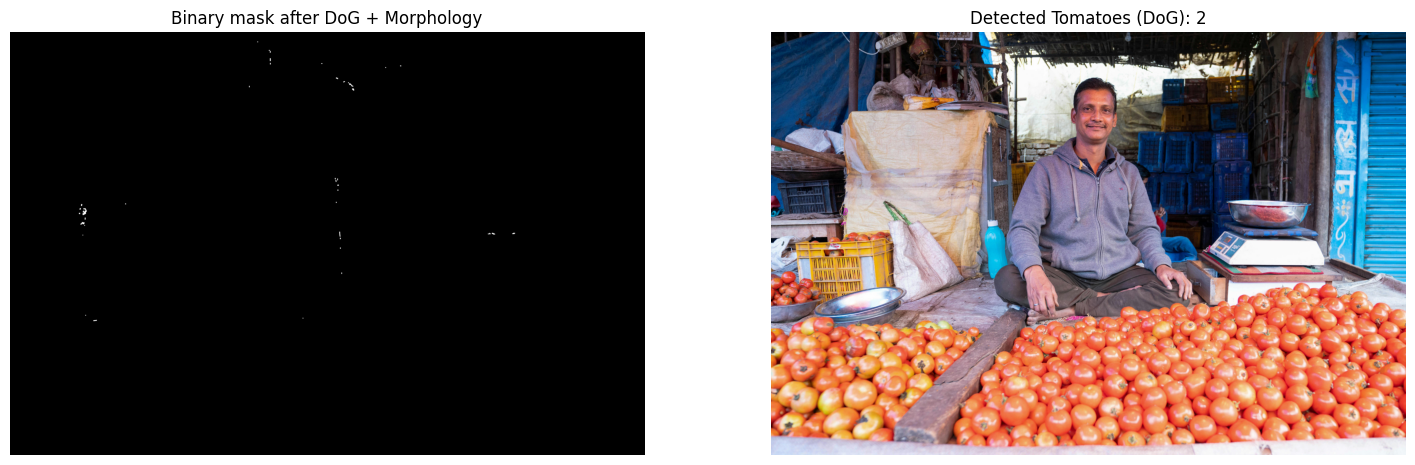

Number of tomatoes detected (DoG method): 2


In [15]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the original color image
image = cv2.imread('/content/51.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ---------------------
# Difference of Gaussians (DoG) Edge Detection
blur_small = cv2.GaussianBlur(gray, (5,5), 1)
blur_large = cv2.GaussianBlur(gray, (9,9), 2)
dog = cv2.subtract(blur_small, blur_large)

# ---------------------
# Thresholding to get binary mask
_, binary = cv2.threshold(dog, 15, 255, cv2.THRESH_BINARY)

# Morphological operations
kernel = np.ones((7,7), np.uint8)

# Close gaps inside tomatoes
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# Remove small noise
opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)

# ---------------------
# Find contours
contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter contours based on area
min_area = 500  # Bigger threshold to ignore small noise
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

# Draw contours
result_image = image_rgb.copy()
cv2.drawContours(result_image, filtered_contours, -1, (255, 0, 255), 2)  # Pink contours

# Count
tomato_count = len(filtered_contours)

# ---------------------
# Display
plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.imshow(opened, cmap='gray')
plt.title('Binary mask after DoG + Morphology')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result_image)
plt.title(f'Detected Tomatoes (DoG): {tomato_count}')
plt.axis('off')
plt.show()

print(f"Number of tomatoes detected (DoG method): {tomato_count}")


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
from sklearn.model_selection import train_test_split

# Load image
image = cv2.imread('/content/51.jpg')
image = cv2.resize(image, (64, 64))
image = image / 255.0  # Normalize

# Assume binary classification: Tomato Seller (Class 1) or Not (Class 0)
# Here we simulate with 1 image (normally, need more)
X = np.expand_dims(image, axis=0)
y = np.array([1])  # 1 for Tomato Seller

# Model
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=5, verbose=1)

# Prediction
pred = model.predict(X)
confidence = pred[0][0]
prediction = int(confidence > 0.5)

print(f"Prediction: {prediction}, Confidence: {confidence:.2f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 0.7090
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 1.0000 - loss: 0.0402
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 0.0043
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 5.3913e-04
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 8.1312e-05
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Prediction: 1, Confidence: 1.00


In [20]:
import cv2
import numpy as np
from sklearn import svm
from skimage.feature import hog

# Load image
image = cv2.imread('/content/51.jpg')
image = cv2.resize(image, (128, 128))
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# HOG feature extraction
features, hog_image = hog(gray, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)

# Assume binary classification, BUT provide data for BOTH classes!
# Here, we're simulating with just one image per class:
X = np.array([features, features])  # Add a dummy feature for the other class
y = np.array([1, 0])  # 1 for Tomato Seller, 0 for Not Tomato Seller

# SVM
clf = svm.SVC(probability=True)
clf.fit(X, y)

# Prediction (using the original image features)
probs = clf.predict_proba(np.array([features]))
confidence = probs[0][1]  # Probability of class 1 (Tomato Seller)
prediction = clf.predict(np.array([features]))

print(f"Prediction: {prediction[0]}, Confidence: {confidence:.2f}")

Prediction: 1, Confidence: 0.50


In [22]:
import cv2
import numpy as np
from sklearn.tree import DecisionTreeClassifier

# Load image
image = cv2.imread('/content/51.jpg')
image = cv2.resize(image, (64, 64))

# Color histogram features
hist = cv2.calcHist([image], [0, 1, 2], None, [8,8,8], [0,256,0,256,0,256])
hist = cv2.normalize(hist, hist).flatten()

# Assume binary classification
X = np.array([hist])
y = np.array([1])  # Tomato Seller

# Decision Tree
clf = DecisionTreeClassifier()
clf.fit(X, y)

# Prediction
prediction = clf.predict(X)
# confidence = clf.predict_proba(X)[0][1]  # This line caused the error
confidence = clf.predict_proba(X)[0][0]  # Get the probability of the single class

print(f"Prediction: {prediction[0]}, Confidence: {confidence:.2f}")

Prediction: 1, Confidence: 1.00


# **APPILCATION:IMAGE CLASSIFICATION**

In [23]:
import tensorflow as tf
import numpy as np
import cv2

# Load and preprocess
image = cv2.imread('/content/51.jpg')
image = cv2.resize(image, (64, 64))
image = image / 255.0  # Normalize pixel values
X = np.expand_dims(image, axis=0)
y = np.array([1])  # Class 1: Tomato Seller

# Simple CNN
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=5, verbose=1)

# Prediction
pred = model.predict(X)
confidence = pred[0][0]
print(f"CNN Prediction: {int(confidence>0.5)}, Confidence: {confidence:.2f}")


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.6022
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.0220
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 1.0000 - loss: 9.9743e-04
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 5.8237e-05
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 1.0000 - loss: 4.2311e-06
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
CNN Prediction: 1, Confidence: 1.00


In [28]:
import cv2
import numpy as np
from sklearn import svm
from skimage.feature import hog

# Load image
image = cv2.imread('/content/51.jpg')
image = cv2.resize(image, (128, 128))
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# HOG feature extraction
features, hog_image = hog(gray, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)

# Assume binary classification, BUT provide data for BOTH classes!
# Here, we're simulating with just one image per class:
X = np.array([features, features])  # Add a dummy feature for the other class
y = np.array([1, 0])  # 1 for Tomato Seller, 0 for Not Tomato Seller

# SVM
clf = svm.SVC(probability=True)
clf.fit(X, y)

# Prediction (using the original image features)
probs = clf.predict_proba(np.array([features]))
confidence = probs[0][1]  # Probability of class 1 (Tomato Seller)
prediction = clf.predict(np.array([features]))

print(f"Prediction: {prediction[0]}, Confidence: {confidence:.2f}")

Prediction: 1, Confidence: 0.50


In [27]:
import cv2
import numpy as np
from sklearn.tree import DecisionTreeClassifier

# Load and preprocess
image = cv2.imread('/content/51.jpg')
image = cv2.resize(image, (64, 64))

# Extract Color Histogram
hist = cv2.calcHist([image], [0,1,2], None, [8,8,8], [0,256,0,256,0,256])
hist = cv2.normalize(hist, hist).flatten()

X = np.array([hist])
y = np.array([1])  # Tomato Seller

# Train Decision Tree
clf = DecisionTreeClassifier()
clf.fit(X, y)

# Prediction
# confidence = clf.predict_proba(X)[0][1]  # Incorrect: Trying to access the probability of the second class which doesn't exist
confidence = clf.predict_proba(X)[0][0]  # Correct: Access the probability of the single class
print(f"Decision Tree (Color) Prediction: {int(confidence>0.5)}, Confidence: {confidence:.2f}")

Decision Tree (Color) Prediction: 1, Confidence: 1.00
